# Phase 1 — Baseline & Profiling

**Goal:** Load GPT-2 124M, measure baseline tokens/sec, and profile to identify bottlenecks.

This notebook is a thin wrapper — all logic lives in `src/` modules.

In [13]:
import sys
sys.path.insert(0, "..")

from src.model import load_model_and_tokenizer
from src.inference import generate, generate_manual
from src.profiling import profile_generate, get_model_memory_footprint, save_profile
from src.benchmark import run_benchmark, compare_benchmarks, plot_speedups
from src.config import QUALITY_CHECK_PROMPTS

## 1. Load Model

In [14]:
model, tokenizer = load_model_and_tokenizer()
print(f"Model: {model.config._name_or_path}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model: gpt2
Parameters: 124,439,808


In [3]:
mem = get_model_memory_footprint(model)
for k, v in mem.items():
    print(f"  {k}: {v}")

  num_parameters: 124439808
  param_memory_mb: 474.7001953125
  buffer_memory_mb: 12.000045776367188
  total_memory_mb: 486.7002410888672
  dtype: torch.float32


## 2. Quick Sanity Check

Generate a few tokens to make sure the model is working.

In [4]:
result = generate(model, tokenizer, "The meaning of life is", max_new_tokens=50)
print(f"tok/s: {result['tok_per_sec']:.2f}")
print(f"Text:  {result['text'][:300]}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


tok/s: 43.09
Text:  The meaning of life is really about what makes human beings living. From the very beginning, life needs to be free of violence, oppression, oppression, oppression, oppression. It needs to be free and equal, free of domination and oppression, both positive and negative, free of


## 3. Profile: HuggingFace `generate` vs Manual Loop

We profile both to understand where time is spent.

In [5]:
# Profile the HuggingFace built-in generate
hf_profile = profile_generate(
    model, tokenizer, "The meaning of life is", generate_fn=generate, max_new_tokens=50
)
print("=== HuggingFace generate() profile ===")
print(hf_profile["profile_stats"])

=== HuggingFace generate() profile ===
         136680 function calls (118436 primitive calls) in 0.622 seconds

   Ordered by: cumulative time
   List reduced from 447 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/1    0.000    0.000    0.621    0.621 _contextlib.py:113(decorate_context)
      2/1    0.000    0.000    0.621    0.621 inference.py:17(generate)
        1    0.000    0.000    0.617    0.617 utils.py:2245(generate)
        1    0.002    0.002    0.617    0.617 utils.py:3508(_sample)
  7550/50    0.004    0.000    0.563    0.011 module.py:1747(_wrapped_call_impl)
  7550/50    0.007    0.000    0.563    0.011 module.py:1755(_call_impl)
       50    0.001    0.000    0.563    0.011 modeling_gpt2.py:1038(forward)
       50    0.002    0.000    0.444    0.009 modeling_gpt2.py:776(forward)
      600    0.001    0.000    0.438    0.001 modeling_layers.py:61(__call__)
 1202/602    0.002    0.000    0.437    0.001 dep

In [6]:
# Profile the manual loop (this is what we'll optimize)
manual_profile = profile_generate(
    model, tokenizer, "The meaning of life is", generate_fn=generate_manual, max_new_tokens=50
)
print("=== Manual loop profile ===")
print(manual_profile["profile_stats"])

=== Manual loop profile ===
         125893 function calls (108088 primitive calls) in 1.302 seconds

   Ordered by: cumulative time
   List reduced from 341 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    1.301    1.301 _contextlib.py:113(decorate_context)
        1    0.004    0.004    1.301    1.301 inference.py:60(generate_manual)
  7550/50    0.005    0.000    1.256    0.025 module.py:1747(_wrapped_call_impl)
  7550/50    0.009    0.000    1.256    0.025 module.py:1755(_call_impl)
       50    0.001    0.000    1.256    0.025 modeling_gpt2.py:1038(forward)
       50    0.003    0.000    0.944    0.019 modeling_gpt2.py:776(forward)
      600    0.001    0.000    0.923    0.002 modeling_layers.py:61(__call__)
 1200/600    0.003    0.000    0.921    0.002 deprecation.py:120(wrapped_func)
      600    0.010    0.000    0.919    0.002 modeling_gpt2.py:398(forward)
     2400    0.005    0.000    0.674 

In [7]:
# Save .prof file for detailed analysis (e.g., snakeviz)
save_profile(
    model, tokenizer, "The meaning of life is",
    generate_fn=generate_manual,
    output_path="../profiling_output/baseline_manual.prof",
    max_new_tokens=50,
)

{'text': "The meaning of life is to be in the present, to go to the future, to remain in the past to experience the world before us. And my idea is that we must go on following life's flow as it unfolds. That is to say, we are not going",
 'num_tokens': 50,
 'elapsed': 1.2998845419933787,
 'tok_per_sec': 38.464954682301844}

## 4. Baseline Benchmark

Full benchmark: 10 prompts × 5 runs each, 200 tokens per run.

In [8]:
print("Benchmarking HuggingFace generate()...")
hf_results = run_benchmark(
    model, tokenizer, generate,
    label="baseline_hf_generate",
    save_path="../benchmark_results/baseline_hf.json",
)
print(f"\nOverall: {hf_results['overall_tok_per_sec_mean']:.2f} ± {hf_results['overall_tok_per_sec_std']:.2f} tok/s")

Benchmarking HuggingFace generate()...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/baseline_hf.json

Overall: 82.52 ± 3.94 tok/s


In [9]:
print("Benchmarking manual loop...")
manual_results = run_benchmark(
    model, tokenizer, generate_manual,
    label="baseline_manual_loop",
    save_path="../benchmark_results/baseline_manual.json",
)
print(f"\nOverall: {manual_results['overall_tok_per_sec_mean']:.2f} ± {manual_results['overall_tok_per_sec_std']:.2f} tok/s")

Benchmarking manual loop...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/baseline_manual.json

Overall: 18.89 ± 2.88 tok/s


In [10]:
compare_benchmarks([hf_results, manual_results])


Label                       tok/s (mean)    tok/s (std)    Speedup
-----------------------------------------------------------------
baseline_hf_generate               82.52           3.94      1.00x
baseline_manual_loop               18.89           2.88      0.23x


  Plot saved to ../benchmark_results/baseline_comparison.png


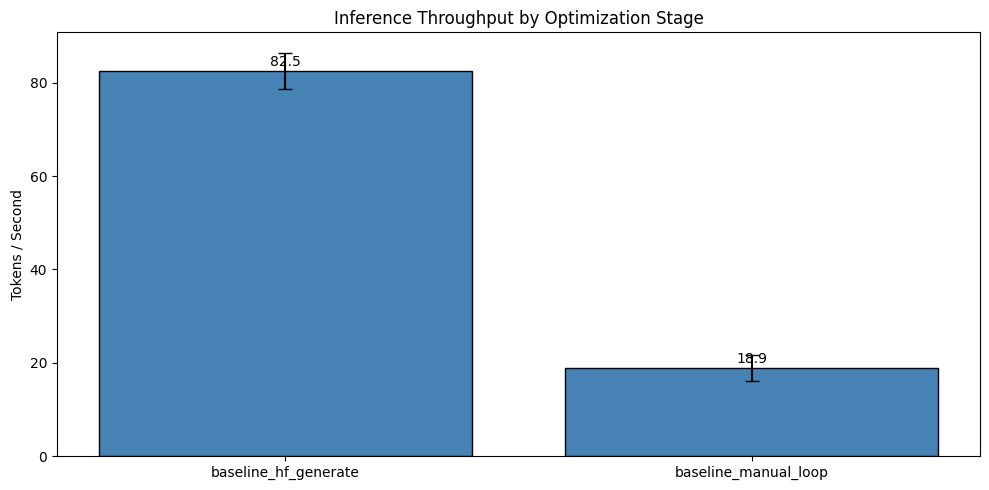

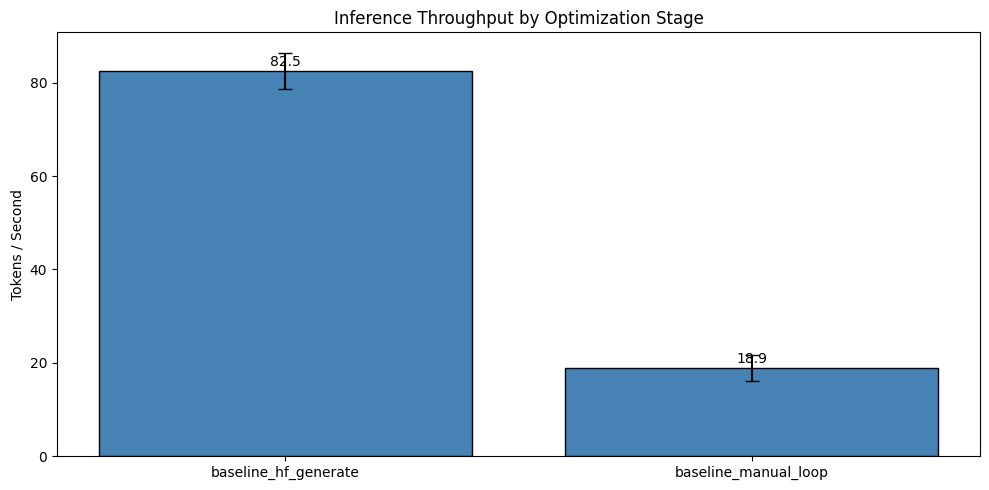

In [11]:
fig = plot_speedups(
    [hf_results, manual_results],
    save_path="../benchmark_results/baseline_comparison.png",
)
fig

## 5. Quality Sanity Check

Verify both methods produce reasonable outputs for factual prompts.

In [12]:
for prompt in QUALITY_CHECK_PROMPTS:
    hf_out = generate(model, tokenizer, prompt, max_new_tokens=30)
    manual_out = generate_manual(model, tokenizer, prompt, max_new_tokens=30)
    print(f"Prompt: {prompt}")
    print(f"  HF:     {hf_out['text'][:150]}")
    print(f"  Manual: {manual_out['text'][:150]}")
    print()

Prompt: What is 2 + 2? The answer is
  HF:     What is 2 + 2? The answer is: A 2/3. But remember that this is not a calculation the calculator will work with.


What is 3 x 4 = 8 -
  Manual: What is 2 + 2? The answer is yes.

Let us recall that the meaning of 2 + 2 is an adjective. There is no meaning of 2 + 2 in 2+3

Prompt: The capital of France is
  HF:     The capital of France is not part of the NATO security agreement which protects its members, while the alliance is an instrumentality of world economi
  Manual: The capital of France is so well known for its small and powerful colonial and industrial enterprises, but its small but great French colonies have lo

Prompt: Water freezes at
  HF:     Water freezes at 1:10.

In the second half, the Ice Cream Cake is still a pretty tasty dessert, but without those frosting effects.

  Manual: Water freezes at night in downtown Austin.

Prompt: The Earth orbits the
  HF:     The Earth orbits the stars that form the solar system around th

## 6. Summary

**Next steps:** Use the profiling output above to identify the top bottlenecks and plan which optimization techniques to apply first (Phase 2).